In [10]:
import pandas as pd
from scipy.stats import ttest_1samp
import sys
sys.path.append('..')
from src.data.data import download_event_file

In [11]:
df = pd.read_csv('../data/preprocessed/memory_preprocessed.csv')
# print number of unique subjects

# CHECKS

## All Participants?

In [12]:
print(f"Number of unique subjects: {df['Participant'].nunique()} unique subjects: {df['Participant'].unique()}")

Number of unique subjects: 35 unique subjects: ['P10' 'P11' 'P12' 'P13' 'P14' 'P15' 'P16' 'P17' 'P18' 'P19' 'P20' 'P21'
 'P22' 'P23' 'P24' 'P25' 'P26' 'P27' 'P30' 'P31' 'P34' 'P35' 'P36' 'P37'
 'P39' 'P41' 'P42' 'P43' 'P44' 'P45' 'P47' 'P48' 'P49' 'P50' 'P51']


In [13]:
participants_to_exclude = ['P11', 'P24', 'P26', 'P28', 'P29', 'P30', 'P32', 'P33', 'P38', 'P39', 'P40', 'P46', 'P49']
df = df[~df['Participant'].isin(participants_to_exclude)]

## New trials ??

In [14]:
print(f"Number of subjects: {df[df['V4'].str.contains('new')]['Participant']}")

Number of subjects: Series([], Name: Participant, dtype: object)


## Picture-viewing task vs. Memory Task

In [15]:
participants = df.groupby('Participant')

for name, group in participants:
    ## add sufix sub-
    name = 'sub-' + name
    print(f"------ Participant: {name}")
    print(f"Number of trials: {len(group)}")
    group = group[group['V4'].str.contains('old')]
    # take only the two first element after splitting by '_'
    group['V4'] = group['V4'].str.split('_').str[:2].str.join('_')

    memory_task_trials = group['V4'].unique()
    events = pd.read_csv(download_event_file(name, 'ses-01'), sep='\t')
    events['event'] = events['event'].str.replace('.jpg', '')
    events = events[events['event'].str.contains('old')]
    events['event'] = events['event'].str.split('_').str[:2].str.join('_')
    picture_viewing_trials = events['event'].unique()

    # check differences between the two tasks
    only_in_memory = set(memory_task_trials) - set(picture_viewing_trials)
    only_in_picture_viewing = set(picture_viewing_trials) - set(memory_task_trials)
    in_both = set(memory_task_trials).intersection(set(picture_viewing_trials))
    print(f"Trials only in memory task: {only_in_memory}")
    print(f"Trials only in picture-viewing task: {only_in_picture_viewing}")
    print(f"Trials in both tasks: {in_both}")

------ Participant: sub-P10
Number of trials: 64
[download_event_file] Executing command: scp boesch@miplabsrv3:/media/RCPNAS/Data3/Alison_island/bids_ackbar/sub-P10/ses-01/func/sub-P10_ses-01_task-viewing_run-01_events.tsv data/preprocessed/sub-P10/func/
[download_event_file] Downloaded event file for sub-P10, ses-01 to data/preprocessed/sub-P10/func.
Trials only in memory task: set()
Trials only in picture-viewing task: {'maya_2', 'wealth_2', 'wealth_5', 'maya_7', 'wealth_6', 'food_2', 'wealth_7', 'food_6', 'food_7', 'maya_3', 'food_3', 'viking_4', 'viking_6', 'wealth_4', 'maya_6', 'drink_8', 'viking_5', 'maya_8', 'wealth_3', 'food_8', 'pirate_7', 'wealth_1', 'pirate_6', 'drink_1', 'food_5', 'viking_8', 'wealth_8', 'maya_4', 'viking_7', 'drink_7', 'maya_5', 'drink_3', 'drink_2', 'pirate_5', 'viking_1', 'pirate_8', 'food_4', 'drink_6', 'pirate_4', 'pirate_2', 'drink_4', 'pirate_3', 'food_1', 'viking_2', 'pirate_1', 'drink_5', 'maya_1', 'viking_3'}
Trials in both tasks: set()
------ Pa

# Analysis

In [16]:
# Restrict analysis to hit -> get rid of True Timed == 100
df = df[(df['Timed'] != 100) & (df['True Time'] != 100)]
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1177 entries, 0 to 2238
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Participant        1177 non-null   object 
 1   V1                 1177 non-null   float64
 2   V4                 1177 non-null   object 
 3   V8                 1177 non-null   object 
 4   V9                 1177 non-null   object 
 5   Placed Confidence  1177 non-null   int64  
 6   Timed              1177 non-null   int64  
 7   Timed Confidence   1177 non-null   int64  
 8   X                  1177 non-null   float64
 9   Y                  1177 non-null   float64
 10  Z                  1177 non-null   float64
 11  True Time          1177 non-null   int64  
 12  Distance           1177 non-null   float64
 13  Classified as old  1177 non-null   int64  
 14  Old                1177 non-null   int64  
dtypes: float64(5), int64(6), object(4)
memory usage: 147.1+ KB


# Spatial

## Confidence

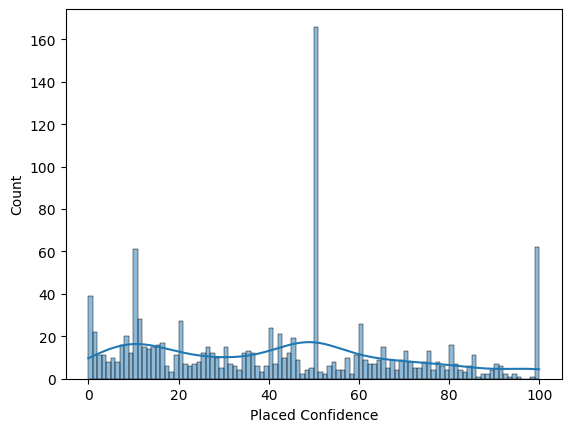

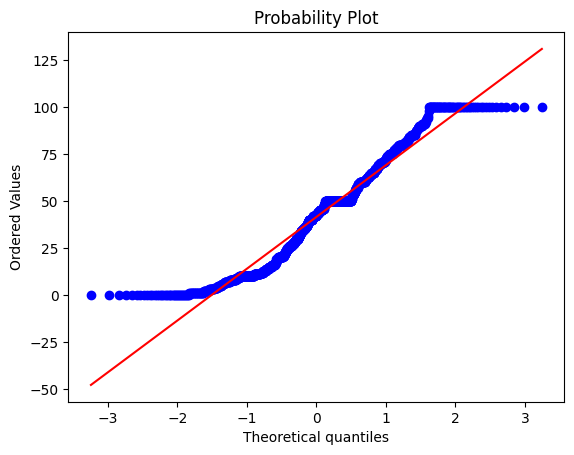

ShapiroResult(statistic=0.9497605046675925, pvalue=1.2966988424713985e-19)

In [17]:

# test normal distribution
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
sns.histplot(df['Placed Confidence'], bins=100, kde=True)
plt.show()
stats.probplot(df['Placed Confidence'], dist="norm", plot=plt)
plt.show()
stats.shapiro(df['Placed Confidence'])

Confidence threshold ≈ 0.00


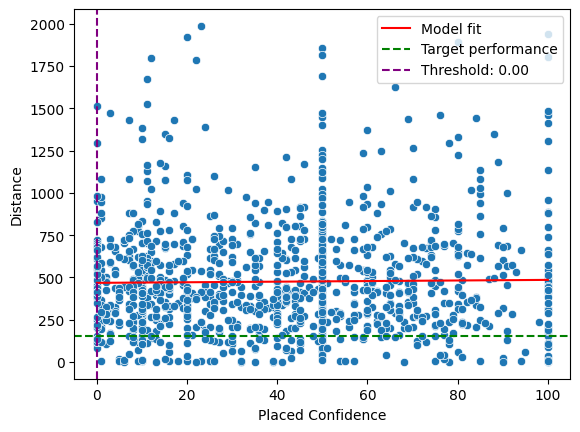

Correlation: 0.01528, p-value: 0.60043


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Fit regression model
X = df['Placed Confidence'].values.reshape(-1, 1)
y = df['Distance'].values
reg = LinearRegression().fit(X, y)

# Predict distance across the confidence range
conf_range = np.linspace(df['Placed Confidence'].min(), df['Placed Confidence'].max(), 100).reshape(-1, 1)
pred_dist = reg.predict(conf_range)

# Choose a "good enough" performance threshold
# e.g., mean - 1 standard deviation (or an empirically defined acceptable distance)
acceptable_distance = y.mean() - y.std()

# Find the confidence level where predicted distance crosses that threshold
conf_threshold = conf_range[np.argmin(np.abs(pred_dist - acceptable_distance))][0]
print(f"Confidence threshold ≈ {conf_threshold:.2f}")

# Plot
sns.scatterplot(x='Placed Confidence', y='Distance', data=df)
plt.plot(conf_range, pred_dist, color='red', label='Model fit')
plt.axhline(acceptable_distance, color='green', linestyle='--', label='Target performance')
plt.axvline(conf_threshold, color='purple', linestyle='--', label=f'Threshold: {conf_threshold:.2f}')
plt.legend()
plt.show()

# print correlation and significance
spatial_corr, spatial_p_value = stats.pearsonr(df['Placed Confidence'], df['Distance'])
print(f"Correlation: {spatial_corr:.5f}, p-value: {spatial_p_value:.5f}")

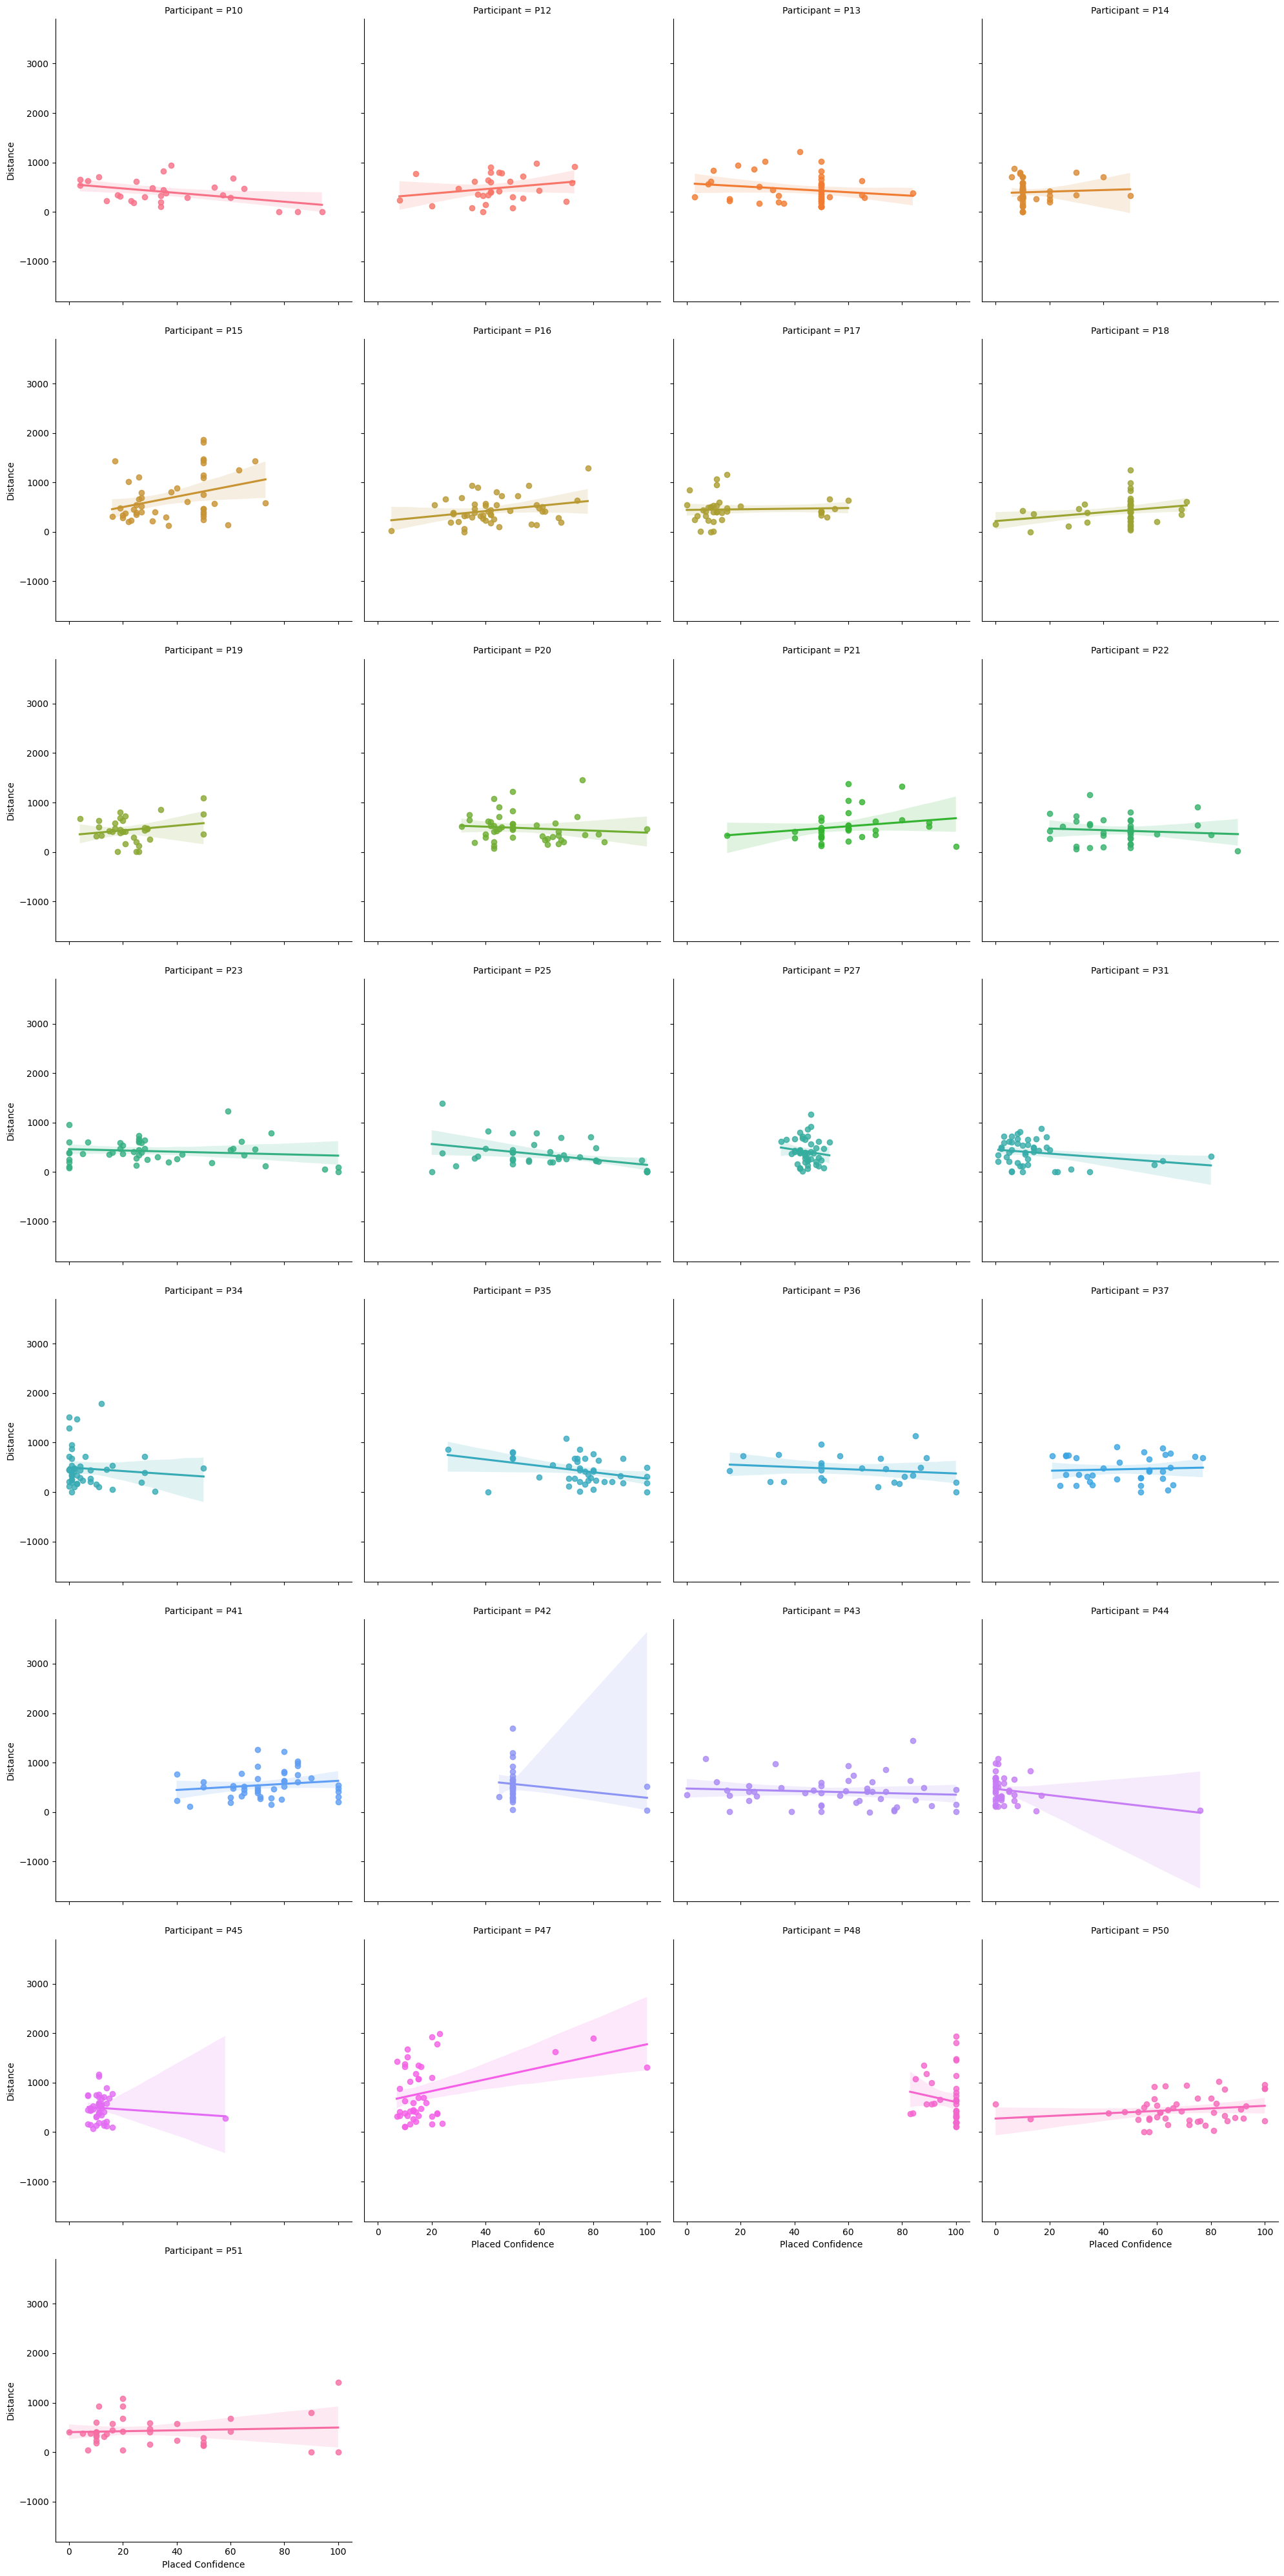

In [19]:
import seaborn as sns
sns.lmplot(x='Placed Confidence', y='Distance', data=df, hue='Participant', col='Participant', col_wrap=4)
plt.show()

In [20]:
# Compute within-subject correlations
per_participant_spatial_corrs = (
    df.groupby('Participant')
      .apply(lambda x: x['Placed Confidence'].corr(x['Distance']))
)

# One-sample t-test: are mean correlations significantly > 0 ?
per_participant_spatial_t, per_participant_spatial_p = ttest_1samp(per_participant_spatial_corrs, 0)
print(f"Mean r = {per_participant_spatial_corrs.mean():.3f}, t = {per_participant_spatial_t:.2f}, p = {per_participant_spatial_p:.4e}")

Mean r = -0.026, t = -0.59, p = 5.5721e-01


/tmp/ipykernel_584660/1968254830.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Participant')


# Temporal

## Confidence

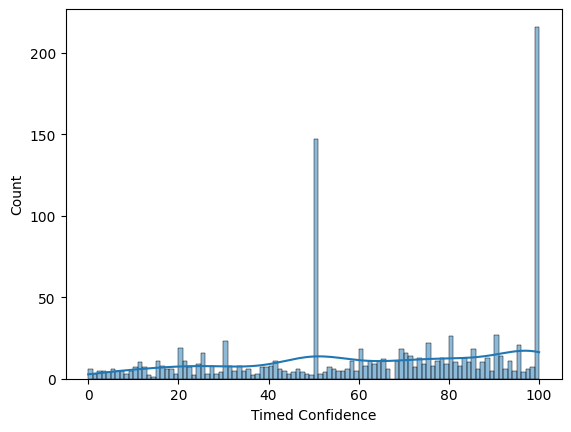

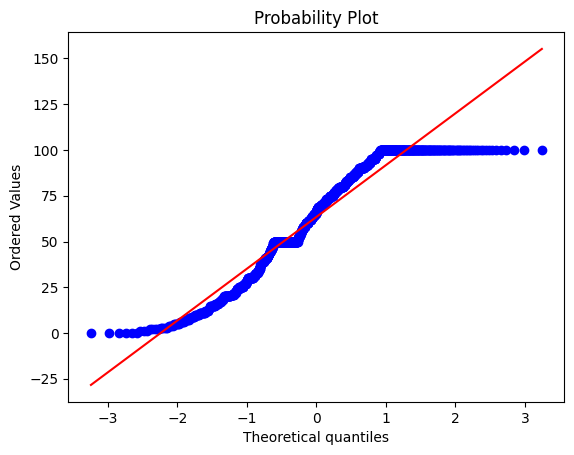

ShapiroResult(statistic=0.9284478827985508, pvalue=2.9155190499060805e-23)

In [21]:
sns.histplot(df['Timed Confidence'], bins=100, kde=True)
plt.show()
# test normal distribution
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
stats.probplot(df['Timed Confidence'], dist="norm", plot=plt)
plt.show()
stats.shapiro(df['Timed Confidence'])

In [22]:
# Compute the difference (error)
df['Timed Error'] = np.abs(df['Timed'] - df['True Time'])
df['Timed Correct'] = df['Timed'] == df['True Time']

/tmp/ipykernel_584660/223661806.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Timed Error'] = np.abs(df['Timed'] - df['True Time'])
/tmp/ipykernel_584660/223661806.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Timed Correct'] = df['Timed'] == df['True Time']


### Overall

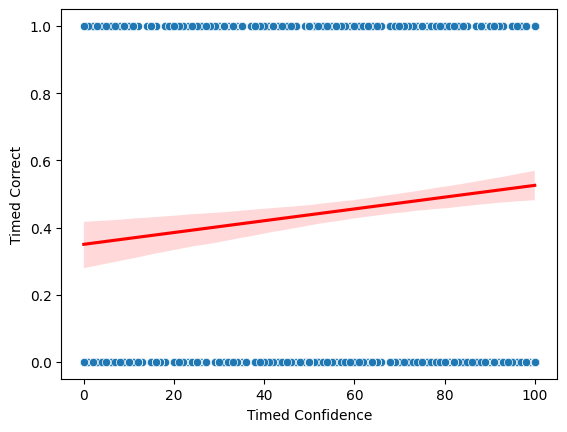

R2: 0.011
Pearsons correlation: 0.103, p-value: 0.0004


In [23]:
# plot
sns.scatterplot(x='Timed Confidence', y='Timed Correct', data=df)
# fit regression line
sns.regplot(x='Timed Confidence', y='Timed Correct', data=df, scatter=False, color='red')
# show r2
plt.show()
# calculate r2
from sklearn.linear_model import LinearRegression
X = df['Timed Confidence'].values.reshape(-1, 1)
y = df['Timed Correct'].values
reg = LinearRegression().fit(X, y)
r2 = reg.score(X, y)
print('R2: %.3f' % r2)
# Pearson correlation
from scipy.stats import pearsonr
temporal_correct_corr, temporal_correct_p = pearsonr(df['Timed Confidence'], df['Timed Correct'])
print('Pearsons correlation: %.3f, p-value: %.4f' % (temporal_correct_corr, temporal_correct_p))

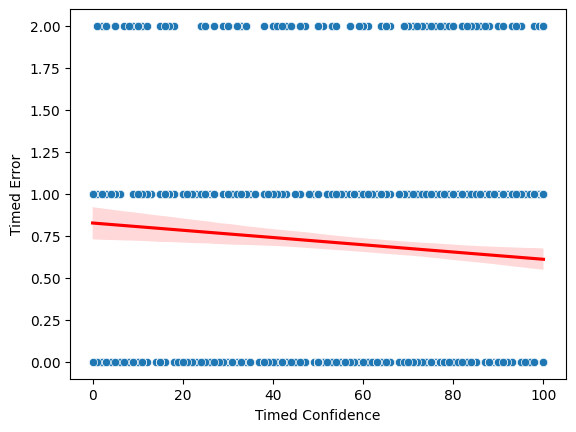

R2: 0.008
Pearsons correlation: -0.088, p-value: 0.0025


In [24]:
# plot
sns.scatterplot(x='Timed Confidence', y='Timed Error', data=df)
# fit regression line
sns.regplot(x='Timed Confidence', y='Timed Error', data=df, scatter=False, color='red')
# show r2
plt.show()
# calculate r2
from sklearn.linear_model import LinearRegression
X = df['Timed Confidence'].values.reshape(-1, 1)
y = df['Timed Error'].values
reg = LinearRegression().fit(X, y)
r2 = reg.score(X, y)
print('R2: %.3f' % r2)
# Pearson correlation
from scipy.stats import pearsonr
temporal_error_corr, temporal_error_p = pearsonr(df['Timed Confidence'], df['Timed Error'])
print('Pearsons correlation: %.3f, p-value: %.4f' % (temporal_error_corr, temporal_error_p))

### Per Patient

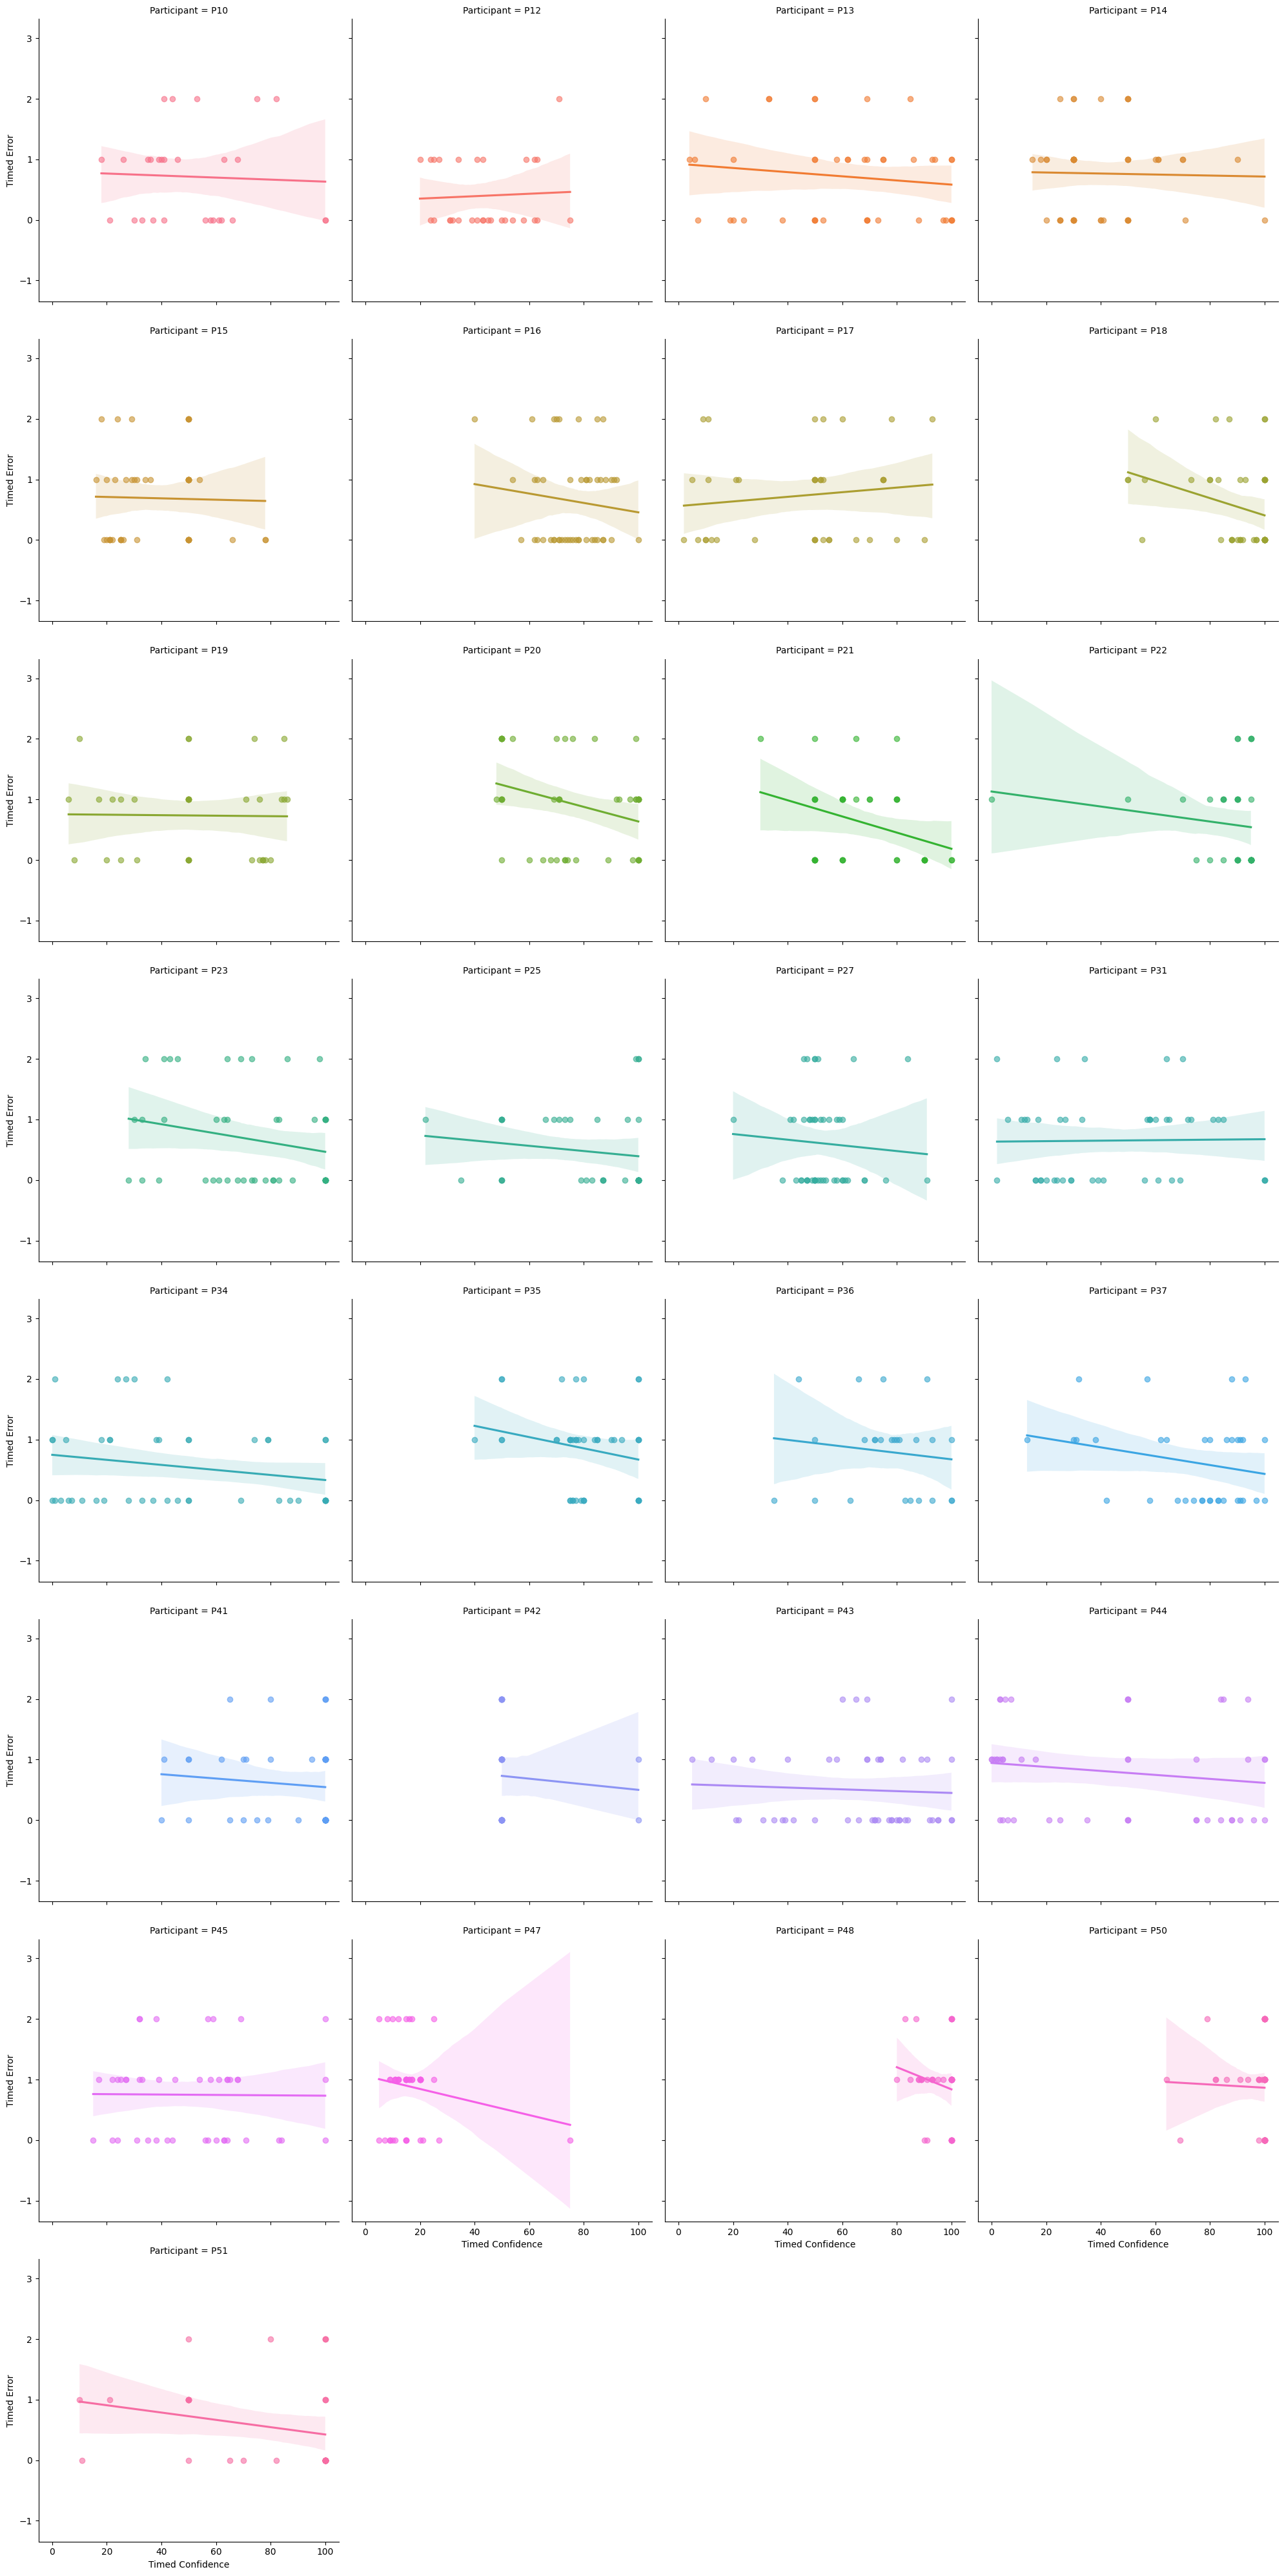

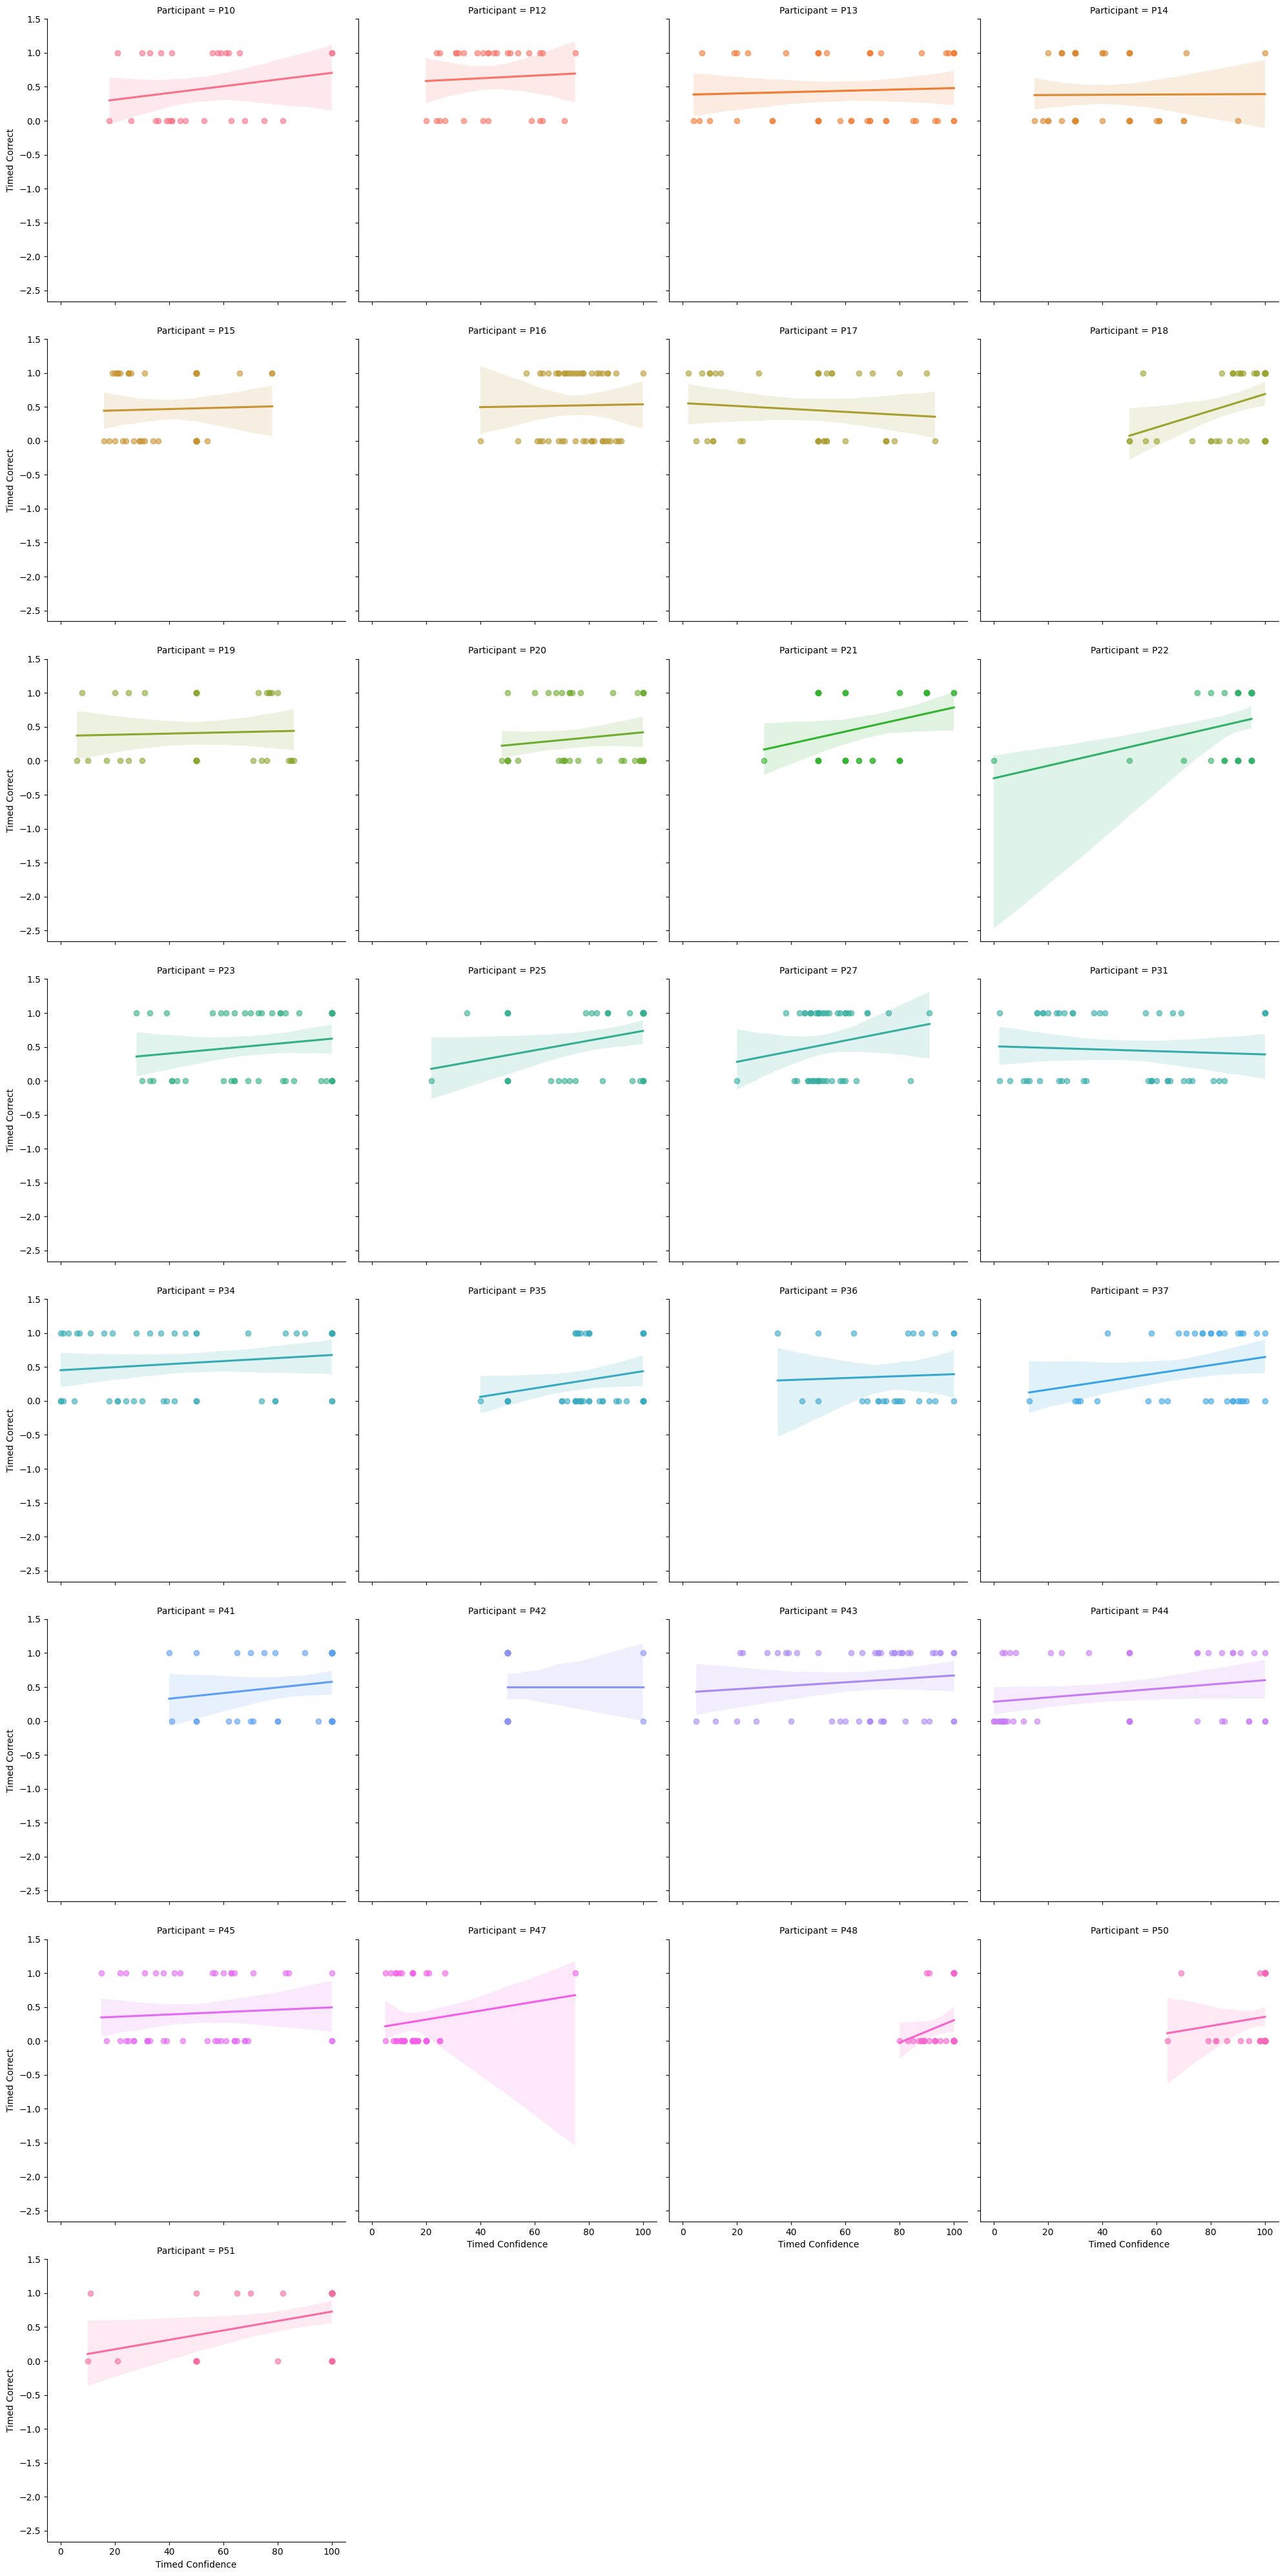

In [25]:

# Plot per participant
sns.lmplot(
    x='Timed Confidence',
    y='Timed Error',
    data=df,
    hue='Participant',
    col='Participant',
    col_wrap=4,
    scatter_kws={'alpha':0.6}
)
plt.show()
# Plot per participant
sns.lmplot(
    x='Timed Confidence',
    y='Timed Correct',
    data=df,
    hue='Participant',
    col='Participant',
    col_wrap=4,
    scatter_kws={'alpha':0.6}
)
plt.show()

In [26]:
# Compute within-subject correlations
per_participant_temporal_correct_corrs = (
    df.groupby('Participant')
      .apply(lambda x: x['Timed Confidence'].corr(x['Timed Correct']))
)

# One-sample t-test: are mean correlations significantly > 0 ?
per_participant_temporal_t, per_participant_temporal_p = ttest_1samp(per_participant_temporal_correct_corrs, 0)
print(f"Mean r = {per_participant_temporal_correct_corrs.mean():.3f}, t = {per_participant_temporal_t:.2f}, p = {per_participant_temporal_p:.4e}")

Mean r = 0.146, t = 6.16, p = 1.1934e-06


/tmp/ipykernel_584660/3429148399.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Participant')


In [27]:
# Compute within-subject correlations
per_participant_temporal_error_corrs = (
    df.groupby('Participant')
      .apply(lambda x: x['Timed Confidence'].corr(x['Timed Error']))
)
# One-sample t-test: are mean correlations significantly > 0 ?
per_participant_temporal_t, per_participant_temporal_p = ttest_1samp(per_participant_temporal_error_corrs, 0)
print(f"Mean r = {per_participant_temporal_error_corrs.mean():.3f}, t = {per_participant_temporal_t:.2f}, p = {per_participant_temporal_p:.4e}")

Mean r = -0.121, t = -5.76, p = 3.5180e-06


/tmp/ipykernel_584660/808337849.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Participant')


# Correlation

## Confidence

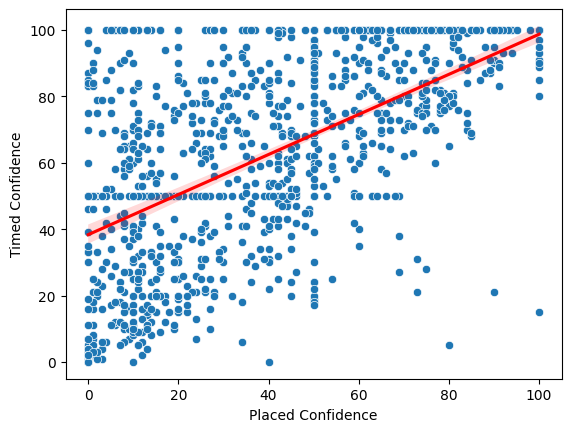

R2: 0.337
Pearsons correlation: 0.581, p-value: 0.0000


In [28]:
# study correlation between placed confidence and timed confidence
# plot
sns.scatterplot(x='Placed Confidence', y='Timed Confidence', data=df)
# fit regression line
sns.regplot(x='Placed Confidence', y='Timed Confidence', data=df, scatter=False, color='red')
# show r2   
plt.show()
# calculate r2
from sklearn.linear_model import LinearRegression
X = df['Placed Confidence'].values.reshape(-1, 1)
y = df['Timed Confidence'].values
reg = LinearRegression().fit(X, y)
r2 = reg.score(X, y)
print('R2: %.3f' % r2)
# Pearson correlation
from scipy.stats import pearsonr
inter_corr, inter_p = pearsonr(df['Placed Confidence'], df['Timed Confidence'])
print('Pearsons correlation: %.3f, p-value: %.4f' % (inter_corr, inter_p))

## Two variable Normal Distribution ? 

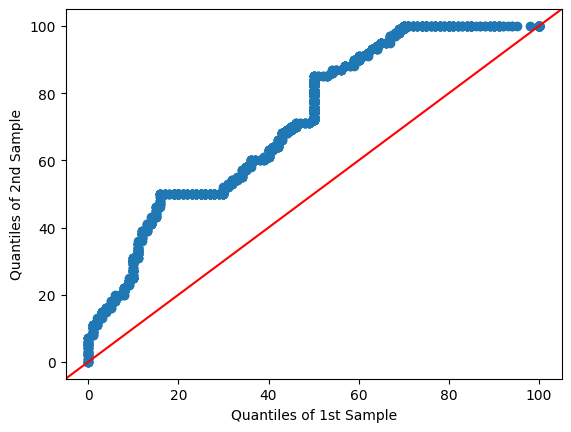

In [29]:
# study if two variables are normally distributed
sm.qqplot_2samples(df['Placed Confidence'], df['Timed Confidence'], line='45')
plt.show()

# Conclusions

In [30]:
# Print conclusions of all findings
print("Findings Summary:")
print("--- Overall ---")
print(f"Spatial Judgment - Correlation between Placed Confidence and Distance: r = {spatial_corr:.2f}, p = {spatial_p_value:.4f}")
print(f"Temporal Judgment - Correlation between Timed Confidence and Timed Correct: r = {temporal_correct_corr:.2f}, p = {temporal_correct_p:.4f}")
print(f"Temporal Judgment - Correlation between Timed Confidence and Timed Error (days): r = {temporal_error_corr:.2f}, p = {temporal_error_p:.4f}")
print(f"Inter-Domain - Correlation between Placed Confidence and Timed Confidence: r = {inter_corr:.2f}, p = {inter_p:.4f}")    

print("--- Per Participant ---")
print(f"Spatial Judgment - Mean within-participant correlation: r = {per_participant_spatial_corrs.mean():.3f}, t = {per_participant_spatial_t:.2f}, p = {per_participant_spatial_p:.4e}")
print(f"Temporal Judgment (Correct) - Mean within-participant correlation: r = {per_participant_temporal_correct_corrs.mean():.3f}, t = {per_participant_temporal_t:.2f}, p = {per_participant_temporal_p:.4e}")
print(f"Temporal Judgment (Error) - Mean within-participant correlation: r = {per_participant_temporal_error_corrs.mean():.3f}, t = {per_participant_temporal_t:.2f}, p = {per_participant_temporal_p:.4e}")    


Findings Summary:
--- Overall ---
Spatial Judgment - Correlation between Placed Confidence and Distance: r = 0.02, p = 0.6004
Temporal Judgment - Correlation between Timed Confidence and Timed Correct: r = 0.10, p = 0.0004
Temporal Judgment - Correlation between Timed Confidence and Timed Error (days): r = -0.09, p = 0.0025
Inter-Domain - Correlation between Placed Confidence and Timed Confidence: r = 0.58, p = 0.0000
--- Per Participant ---
Spatial Judgment - Mean within-participant correlation: r = -0.026, t = -0.59, p = 5.5721e-01
Temporal Judgment (Correct) - Mean within-participant correlation: r = 0.146, t = -5.76, p = 3.5180e-06
Temporal Judgment (Error) - Mean within-participant correlation: r = -0.121, t = -5.76, p = 3.5180e-06


# Per Timed Answers

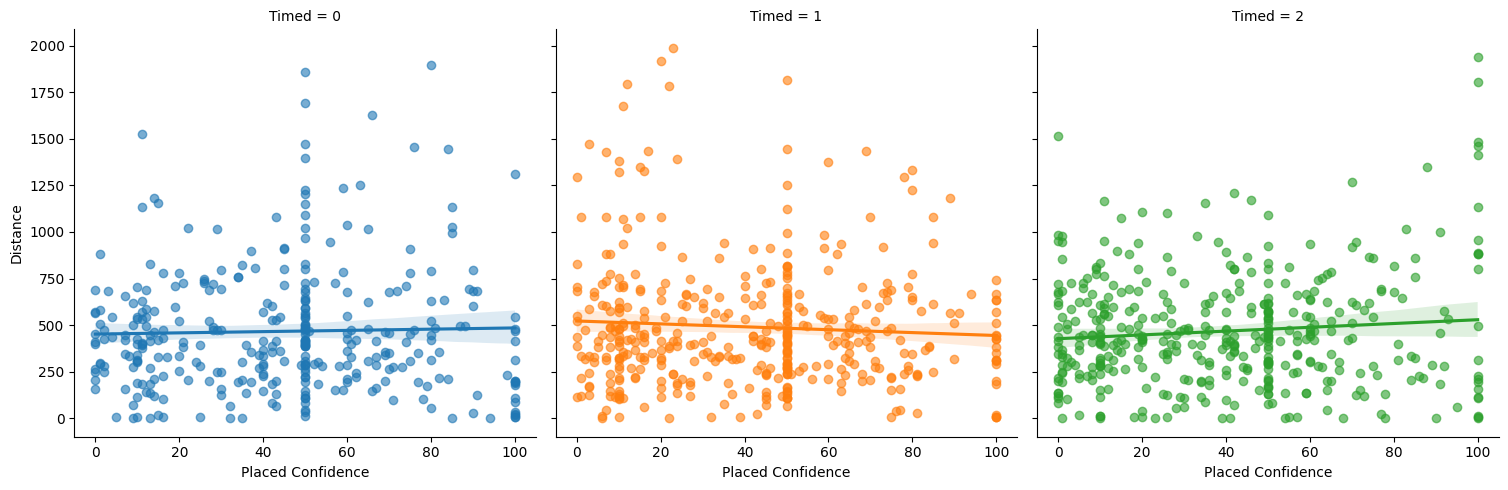

In [31]:
sns.lmplot(
    x='Placed Confidence',
    y='Distance',
    data=df,
    hue='Timed',
    col='Timed',
    col_wrap=4,
    scatter_kws={'alpha':0.6}
)

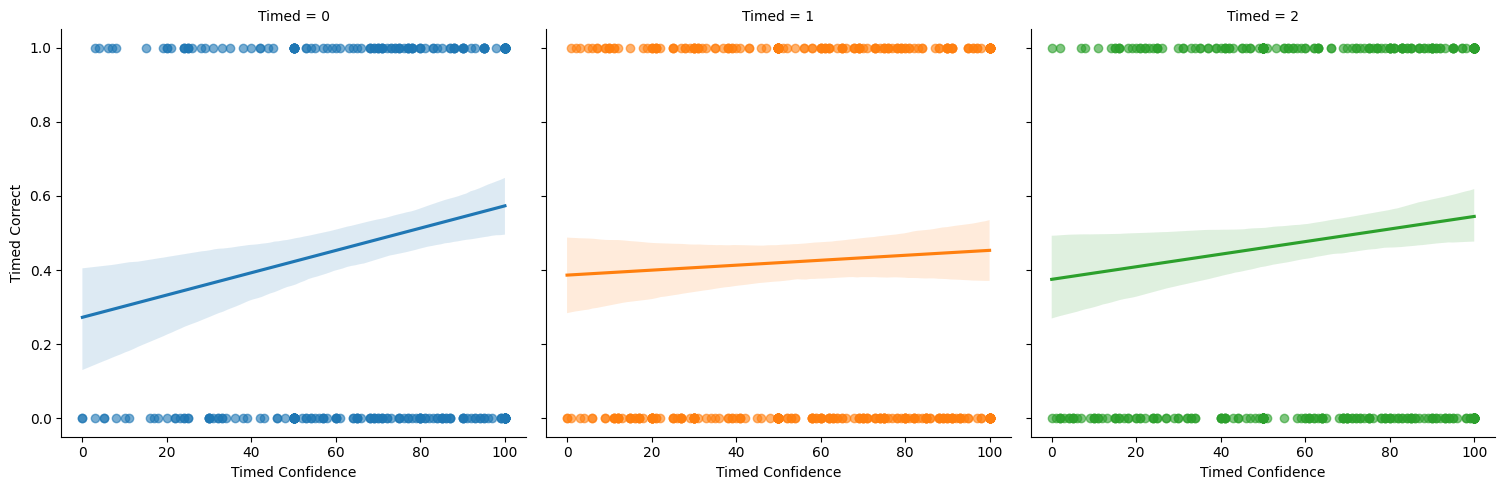

In [32]:
sns.lmplot(
    x='Timed Confidence',
    y='Timed Correct',
    data=df,
    hue='Timed',
    col='Timed',
    col_wrap=4,
    scatter_kws={'alpha':0.6}
)